<a href="https://colab.research.google.com/github/Ashcodes69/Models/blob/main/REAL_%26_FAKE_NEWS_DETECTOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***REAL VS FAKE NEWS DETECTOR***

# *Pre- Processing*
*Since we have two files* **Fake.csv** **True.csv** *we have to combine them into a single dataframe and give them labels*


1. 0 for fake
2. 1 for true

**Dataset Download Link:** https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')
df_fake = pd.read_csv("/content/drive/MyDrive/archive/Fake.csv")
df_true = pd.read_csv("/content/drive/MyDrive/archive/True.csv")

Mounted at /content/drive


In [ ]:
import pandas as pd

# df_fake = pd.read_csv("/content/Fake.csv")
# df_true = pd.read_csv("/content/True.csv")
df_fake["label"] = 0
df_true["label"] = 1

df = pd.concat([df_fake, df_true])

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df["content"] = df["title"] + " " + df["text"]

df = df[["content", "label"]]

df.head()

,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


# Test-cleaning

In [ ]:
import re
import string

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove text in square brackets
    text = re.sub(r'\[.*?\]', '', text)
    # Remove punctuation
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    # This replaces any sequence of digits with the word 'number'
    text = re.sub(r'\d+', 'number', text)
    return text

df["content"] = df["content"].apply(clean_text)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  44898 non-null  object
 1   label    44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 701.7+ KB


# Convert words into numbers

## 1. Tokenization

In [ ]:
df["tokens"] = df["content"].apply(lambda x: x.split())

## 2. Building a Vocabulary

In [ ]:
from collections import Counter

# Count all words in dataset
all_words = [word for tokens in df["tokens"] for word in tokens]
word_counts = Counter(all_words)

# Keep words that appear at least 2 or 3 times to reduce noise
vocab = {word: i+2 for i, (word, count) in enumerate(word_counts.most_common()) if count > 2}

# Add special tokens: 0 for padding (empty space) and 1 for unknown words
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

## 3. Numerical Encoding

In [ ]:
def encode_tokens(tokens):
    return [vocab.get(token, 1)for token in tokens]

df["encoded"] = df["tokens"].apply(encode_tokens)

In [ ]:
df.head()

,content,label,tokens,encoded
0,ben stein calls out numberth circuit court com...,0,"[ben, stein, calls, out, numberth, circuit, co...","[1727, 3170, 575, 56, 706, 2370, 131, 1077, 5,..."
1,trump drops steve bannon from national securit...,1,"[trump, drops, steve, bannon, from, national, ...","[16, 5479, 1426, 1474, 27, 126, 122, 541, 109,..."
2,puerto rico expects us to lift jones act shipp...,1,"[puerto, rico, expects, us, to, lift, jones, a...","[1207, 1549, 3380, 32, 3, 3619, 1524, 341, 608..."
3,oops trump just accidentally confirmed he lea...,0,"[oops, trump, just, accidentally, confirmed, h...","[7812, 16, 77, 5862, 807, 14, 2315, 1371, 268,..."
4,donald trump heads for scotland to reopen a go...,1,"[donald, trump, heads, for, scotland, to, reop...","[71, 16, 1912, 11, 5058, 3, 7665, 5, 2108, 307..."


# Pipeline

1. Padding: Every article in a "batch" must be the same length (e.g., 500 words). If an article is shorter, we add zeros at the end.
2. Batching: Feeding all 40,000 articles at once will crash your computer's memory. We feed them in small groups (batches), usually 32 or 64 at a time.

## Dataset class

* It's a PyTorch Dataset object — a custom Python class that wraps your data in a format PyTorch's training pipeline understands.
* Its main purpose is to feed into a DataLoader, which handles batching and shuffling during training
* Think of it as a read-only, index-able wrapper around your DataFrame columns — the DataFrame's job is done once the Dataset is created

In [ ]:
import torch
from torch.utils.data import Dataset

class NewsDataset(Dataset):
    def __init__(self, encoded_sentences, labels):
        self.sentences = [torch.tensor(s) for s in encoded_sentences]
        self.labels = torch.tensor(labels.values)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sentences[idx], self.labels[idx]

dataset = NewsDataset(df["encoded"], df["label"])

## Collate Function

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    sentences, labels = zip(*batch)

    sentances_padded = pad_sequence(sentences,
                                    batch_first=True,
                                    padding_value=0)

    return sentances_padded, torch.stack(labels)

## create Dataloader
1. train_loader
2. test_loader

In [ ]:
from torch.utils.data import DataLoader, random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    dataset=test_data,
    batch_size=32,
    shuffle=False,
    collate_fn= collate_fn
)

# Model

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
import torch.nn as nn

class FakeNewsModel_V0(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(FakeNewsModel_V0, self).__init__()
        # Embeding layer
        self.embeding = nn.Embedding(num_embeddings=vocab_size,
                                     embedding_dim=embed_dim,
                                     padding_idx=0)

        # 2. LSTM Layer (batch_first=True makes it match our DataLoader)
        self.lstm = nn.LSTM(input_size=embed_dim,
                            hidden_size=hidden_dim,
                            batch_first=True)

        # 3. Final Linear Layer for prediction
        self.fc = nn.Linear(in_features=hidden_dim, out_features=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embeding(x)
        _, (hidden, _) = self.lstm(x)
        out = self.fc(hidden[-1])
        return self.sigmoid(out)

model_0 = FakeNewsModel_V0(vocab_size=len(vocab),
                           embed_dim=64,
                           hidden_dim=128).to(device)

In [ ]:
model_0

FakeNewsModel_V0(
  (embeding): Embedding(81696, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

# Loss func and Optimizer

In [ ]:
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)
criterion = nn.BCELoss()

# Train and test loop

In [ ]:
# Store metrics for plotting
history = {
    "train_loss": [], "train_acc": [],
    "test_loss":  [], "test_acc":  []
}

epochs = 10
torch.cuda.empty_cache()
for epoch in range(epochs):

    # ── Training ──────────────────────────────────────────
    model_0.train()
    train_loss, train_acc = 0, 0

    for X, y in train_loader:
        X = X.to(device)
        y = y.to(device).float().unsqueeze(1)

        pred = model_0(X)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc  += ((pred > 0.5).float() == y).float().mean().item()

    # ── Evaluation ────────────────────────────────────────
    model_0.eval()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for X, y in test_loader:
            X = X.to(device)
            y = y.to(device).float().unsqueeze(1)

            pred = model_0(X)
            loss = criterion(pred, y)

            test_loss += loss.item()
            test_acc  += ((pred > 0.5).float() == y).float().mean().item()

    # ── Logging ───────────────────────────────────────────
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc  = train_acc  / len(train_loader)
    avg_test_loss  = test_loss  / len(test_loader)
    avg_test_acc   = test_acc   / len(test_loader)

    # Store in history
    history["train_loss"].append(avg_train_loss)
    history["train_acc"].append(avg_train_acc)
    history["test_loss"].append(avg_test_loss)
    history["test_acc"].append(avg_test_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f} | "
          f"Test Loss: {avg_test_loss:.4f} | Test Acc: {avg_test_acc:.2f}")

Epoch 1/10 | Train Loss: 0.6853 | Train Acc: 0.52 | Test Loss: 0.6817 | Test Acc: 0.53
Epoch 2/10 | Train Loss: 0.6854 | Train Acc: 0.52 | Test Loss: 0.6815 | Test Acc: 0.53
Epoch 3/10 | Train Loss: 0.5605 | Train Acc: 0.67 | Test Loss: 0.4541 | Test Acc: 0.77
Epoch 4/10 | Train Loss: 0.4228 | Train Acc: 0.80 | Test Loss: 0.4474 | Test Acc: 0.77
Epoch 5/10 | Train Loss: 0.4590 | Train Acc: 0.76 | Test Loss: 0.6779 | Test Acc: 0.53
Epoch 6/10 | Train Loss: 0.3802 | Train Acc: 0.79 | Test Loss: 0.0965 | Test Acc: 0.97
Epoch 7/10 | Train Loss: 0.0986 | Train Acc: 0.97 | Test Loss: 0.0760 | Test Acc: 0.98
Epoch 8/10 | Train Loss: 0.0543 | Train Acc: 0.99 | Test Loss: 0.0532 | Test Acc: 0.99
Epoch 9/10 | Train Loss: 0.0484 | Train Acc: 0.99 | Test Loss: 0.0861 | Test Acc: 0.98
Epoch 10/10 | Train Loss: 0.0356 | Train Acc: 0.99 | Test Loss: 0.0607 | Test Acc: 0.99


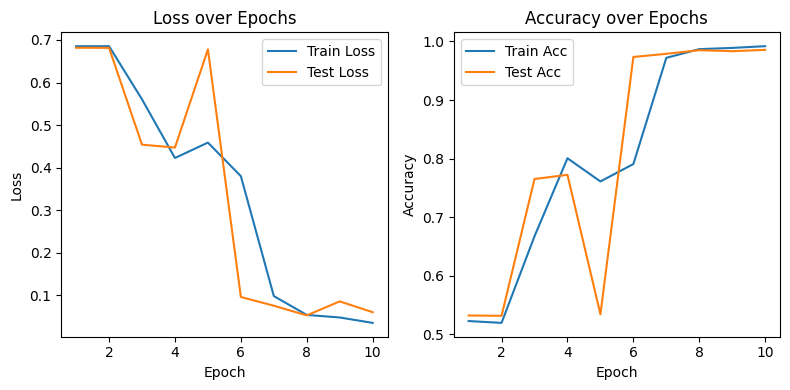

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))
epoch_range = range(1, epochs + 1)

# Loss plot
ax1.plot(epoch_range, history["train_loss"], label="Train Loss")
ax1.plot(epoch_range, history["test_loss"],  label="Test Loss")
ax1.set_title("Loss over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

# Accuracy plot
ax2.plot(epoch_range, history["train_acc"], label="Train Acc")
ax2.plot(epoch_range, history["test_acc"],  label="Test Acc")
ax2.set_title("Accuracy over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

# Save the model

In [ ]:
import torch
torch.save(model_0.state_dict(), '/content/drive/MyDrive/fake_news_model.pth')

## To load it back latter

In [ ]:
model_1 = FakeNewsModel_V0(vocab_size=len(vocab), embed_dim=64, hidden_dim=128)
model_1.load_state_dict(torch.load('/content/drive/MyDrive/fake_news_model.pth'))
model_1.to(device)
model_1.eval()

FakeNewsModel_V0(
  (embeding): Embedding(81696, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [ ]:
def predict_article(text, model, vocab, device, max_len=200):
    model.eval()

    # Step 1 — Clean text (same as training)
    text = re.sub(r'\[.*?\]', '', text.lower())
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\d+', 'number', text)

    # Step 2 — Tokenize
    tokens = text.split()

    # Step 3 — Encode using vocab
    encoded = [vocab.get(token, 1) for token in tokens]  # 1 = <UNK>

    # Step 4 — Truncate or Pad to max_len
    if len(encoded) > max_len:
        encoded = encoded[:max_len]                        # truncate
    else:
        encoded = encoded + [0] * (max_len - len(encoded)) # pad with 0 = <PAD>

    # Step 5 — Convert to tensor and add batch dimension
    tensor = torch.tensor(encoded).unsqueeze(0).to(device) # shape (1, max_len)

    # Step 6 — Forward pass
    with torch.inference_mode():
        output = model(tensor)                             # shape (1, 1)
        prediction = (output > 0.5).int().item()          # 0 or 1
        confidence = output.item()                         # probability

    label = "FAKE" if prediction == 0 else "REAL"
    print(f"Prediction : {label}")
    print(f"Confidence : {confidence:.2%}")
    print(output)

    return prediction

In [ ]:

article = """
        weather reports says that the weather is mostly pleasent today
"""

predict_article(article, model_1, vocab, device)

Prediction : FAKE
Confidence : 12.22%
tensor([[0.1222]], device='cuda:0')


0